In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [166]:
def fried(a, C, L, k):
    """Hubble function: 
    H**2 = C/a**3 + L/3 - 3*k/a**2
    """
    
    rho_m = C/a**3
    rho_l = L*a/a
    rho_k = - 3*k/a**2
    H2 = (rho_m + rho_l + rho_k)/3
    
    return H2, rho_m, rho_l, rho_k

In [3]:
H2, rho_m, rho_l, rho_k = fried(0.1,1,1,1)
print(H2)

233.6666666666666


In [320]:
C = -1; 
Lc = 4/C**2;
L = -0.001*Lc; k = -1;
a = np.logspace(-5,2,500)
H2, rho_m, rho_l, rho_k = fried(a,C,L,k)

Text(0, 0.5, 'densidades')

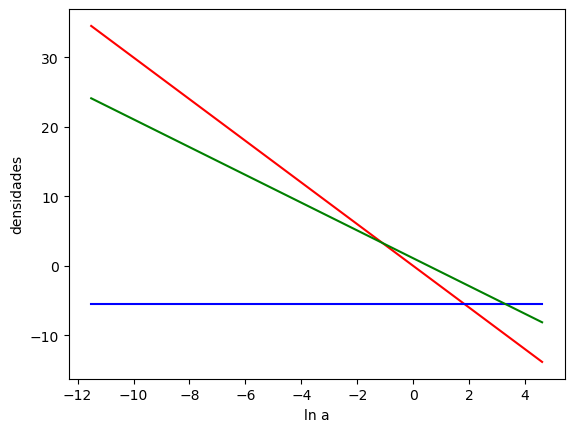

In [321]:
#plt.plot(np.log(a),np.log(abs(rho_m)),'r',np.log(a),np.log(abs(rho_l)),'b',np.log(a),np.log(np.abs(rho_k)),'g--',np.log(a),np.log(abs(3*H2)),'k')
plt.plot(np.log(a),np.log(abs(rho_m)),'r',np.log(a),np.log(abs(rho_l)),'b',np.log(a),np.log(np.abs(rho_k)),'g')
plt.xlabel('ln a')
plt.ylabel('densidades')

In [322]:
def sol_fried(S,t):
    a, da = S
    rho_m = C/a**3
    rho_l = L
    rho_k = - 3*k/a**2
    H2 = (rho_m + rho_l + rho_k)/3
    dH = -1/2*(rho_m + 2/3*rho_k)
    H = np.sqrt(H2) 
    #da = H*a
    dda = (H2 + dH)*a
    y = [0,0]
    y[0] = da
    y[1] = dda
    return y    

Text(0, 0.5, 'factor de escala a(t)')

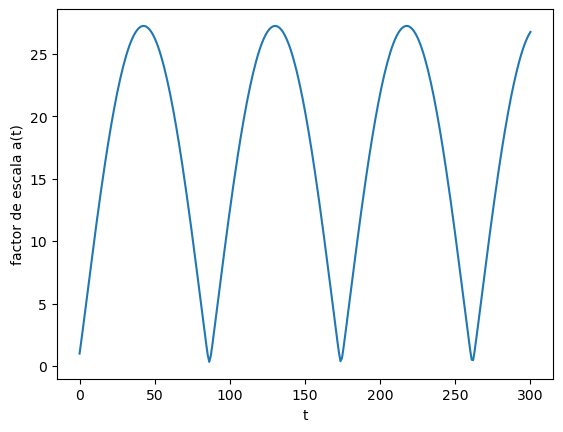

In [326]:
from scipy.integrate import odeint
ti = 0; tf = 300;
ac= C/2
ai = 1; 
rho_mi = C/ai**3
rho_li = L
rho_ki = - 3*k/ai**2
H2i = (rho_mi + rho_li + rho_ki)/3
Hi = np.sqrt(H2i)
dai = Hi*ai
t = np.linspace(ti,tf,300)

Si = [ai, dai]
boo = odeint(sol_fried,Si,t)
b = boo[:,0]
db = boo[:,1]
plt.plot(t,b)
plt.xlabel('t')
plt.ylabel('factor de escala a(t)')